<a href="https://colab.research.google.com/github/chavan1807chinmayi-create/CSL701-CE03_Machine-Learning-Lab/blob/main/CE03_ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME :- CHINMAYI MILIND CHAVAN

ROLL_NO. :- CE03

BATCH :- CE1


Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


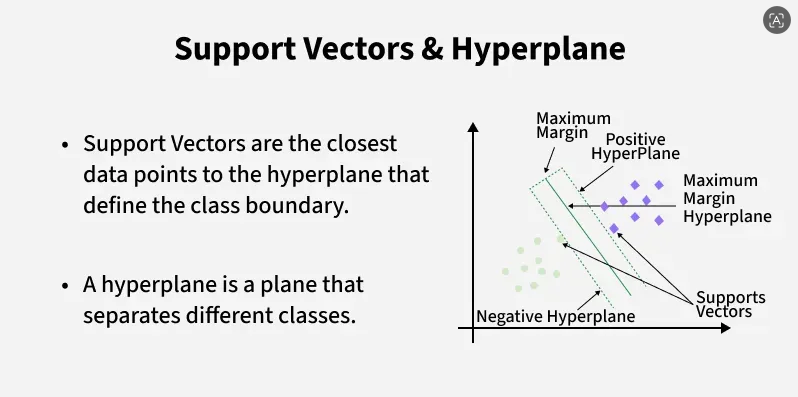
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a Pandas DataFrame from the dataset
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

In [3]:
# Display the first 5 rows of the DataFrame
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Task 2: Explore the Dataset

In [9]:
# Display the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

Shape of the DataFrame: (150, 5)


In [10]:
# Display information about the DataFrame (data types, non-null counts)
print("\nInformation about the DataFrame:")
df.info()


Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [11]:
# Display descriptive statistics of the DataFrame
print("\nDescriptive statistics of the DataFrame:")
display(df.describe())


Descriptive statistics of the DataFrame:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
# Display the distribution of species
print("\nSpecies distribution:")
display(df['species'].value_counts())


Species distribution:


,count
species,
setosa,50
versicolor,50
virginica,50


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [13]:
# Separate features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display the first few rows of features
print("\nFirst 5 rows of Features (X):")
display(X.head())

Features (X) shape: (150, 4)
Target (y) shape: (150,)

First 5 rows of Features (X):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)


In [15]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFirst 5 rows of scaled X_train:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())


First 5 rows of scaled X_train:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.413416,-1.462003,-0.099511,-0.323398
1,0.551222,-0.502563,0.717703,0.353032
2,0.671802,0.217016,0.951192,0.758890
3,0.912961,-0.022844,0.309096,0.217746
4,1.636440,1.416315,1.301427,1.705891


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [16]:
from sklearn.svm import SVC

# Create an SVM classifier with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Train the model
svm_linear.fit(X_train_scaled, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [17]:
# Make predictions on the scaled test data
y_pred_linear_svm = svm_linear.predict(X_test_scaled)

print("First 10 predictions of Linear SVM:")
display(y_pred_linear_svm[:10])

First 10 predictions of Linear SVM:


array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'virginica', 'versicolor'],
      dtype=object)

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy_linear_svm = accuracy_score(y_test, y_pred_linear_svm)
print(f"Accuracy of Linear SVM: {accuracy_linear_svm:.4f}")

Accuracy of Linear SVM: 0.9778


In [19]:
# Generate Confusion Matrix
conf_matrix_linear_svm = confusion_matrix(y_test, y_pred_linear_svm)
print("\nConfusion Matrix for Linear SVM:")
display(pd.DataFrame(conf_matrix_linear_svm, index=svm_linear.classes_, columns=svm_linear.classes_))


Confusion Matrix for Linear SVM:


,setosa,versicolor,virginica
setosa,19,0,0
versicolor,0,12,1
virginica,0,0,13


In [20]:
# Generate Classification Report
class_report_linear_svm = classification_report(y_test, y_pred_linear_svm)
print("\nClassification Report for Linear SVM:")
print(class_report_linear_svm)


Classification Report for Linear SVM:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

### Create the 2-D Dataset and Split

In [21]:
# Select only 'petal length (cm)' and 'petal width (cm)' for visualization
X_2d = df[['petal length (cm)', 'petal width (cm)']]

# Split the 2-D dataset into training and testing sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.3, random_state=42)

print(f"X_train_2d shape: {X_train_2d.shape}")
print(f"X_test_2d shape: {X_test_2d.shape}")

X_train_2d shape: (105, 2)
X_test_2d shape: (45, 2)


### Scale the 2-D Data

In [22]:
# Scale the 2-D features using StandardScaler
scaler_2d = StandardScaler()
X_train_scaled_2d = scaler_2d.fit_transform(X_train_2d)
X_test_scaled_2d = scaler_2d.transform(X_test_2d)

print("First 5 rows of scaled X_train_2d:")
display(pd.DataFrame(X_train_scaled_2d, columns=X_2d.columns).head())

First 5 rows of scaled X_train_2d:


,petal length (cm),petal width (cm)
0,-0.099511,-0.323398
1,0.717703,0.353032
2,0.951192,0.758890
3,0.309096,0.217746
4,1.301427,1.705891


### Train Linear SVM on 2-D Data

In [23]:
# Train an SVM classifier with a linear kernel on the 2-D scaled data
svm_linear_2d = SVC(kernel='linear', random_state=42)
svm_linear_2d.fit(X_train_scaled_2d, y_train_2d)

print("Linear SVM model (2D) trained successfully.")

Linear SVM model (2D) trained successfully.


### Plot Decision Boundary for Linear SVM (2-D)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


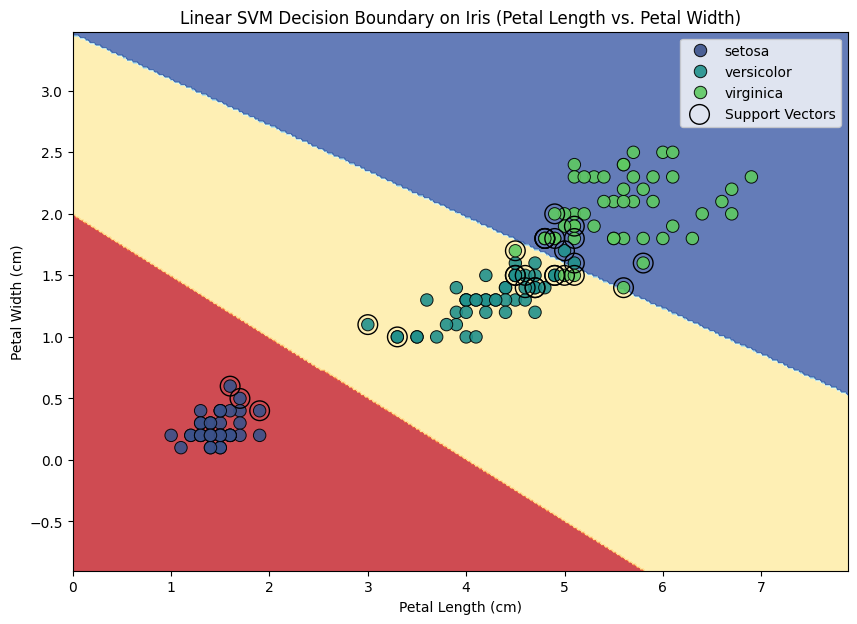

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a mesh to plot the decision boundary
x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the mesh grid points after scaling
Z_str = svm_linear_2d.predict(scaler_2d.transform(np.c_[xx.ravel(), yy.ravel()]))

# Map species names to numerical values for plotting (if not already done)
# This is needed because contourf needs numerical values for levels
# We'll use the original iris target mapping for consistency
color_dict = {name: i for i, name in enumerate(iris.target_names)}

# Convert predicted string labels to numerical values for contourf
Z = np.array([color_dict[label] for label in Z_str])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the actual data points
sns.scatterplot(
    x=df.iloc[:, 2], y=df.iloc[:, 3], hue=df['species'],
    palette='viridis', s=80, alpha=0.9, edgecolor='k'
)

# Highlight support vectors (scaled back to original feature space if needed for direct plotting)
# For simplicity, we'll plot them on the scaled space, but for context we can plot them on the original space.
# Since we are plotting original data points and decision boundary in original feature space,
# we need to transform support vectors back to original scale to highlight them correctly.

# Get support vectors in scaled 2D space
support_vectors_scaled_2d = svm_linear_2d.support_vectors_
# Inverse transform support vectors to original feature space for plotting
support_vectors_original_2d = scaler_2d.inverse_transform(support_vectors_scaled_2d)

plt.scatter(support_vectors_original_2d[:, 0], support_vectors_original_2d[:, 1],
            s=200, facecolors='none', edgecolors='k', marker='o', label='Support Vectors')


plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Linear SVM Decision Boundary on Iris (Petal Length vs. Petal Width)')
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [26]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression model on the scaled 2-D training data
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled_2d, y_train_2d)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Plot Decision Boundary for Logistic Regression (2-D)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


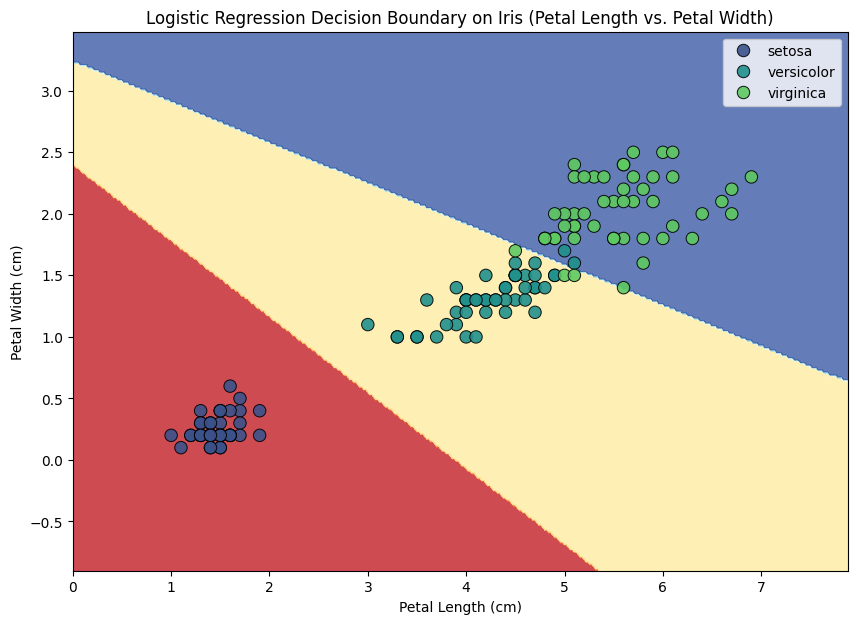

In [27]:
# Predict on the mesh grid points using the Logistic Regression model
Z_log_reg_str = log_reg.predict(scaler_2d.transform(np.c_[xx.ravel(), yy.ravel()]))

# Convert predicted string labels to numerical values for contourf
Z_log_reg = np.array([color_dict[label] for label in Z_log_reg_str])
Z_log_reg = Z_log_reg.reshape(xx.shape)

# Plot the decision boundary for Logistic Regression
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_log_reg, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the actual data points
sns.scatterplot(
    x=df.iloc[:, 2], y=df.iloc[:, 3], hue=df['species'],
    palette='viridis', s=80, alpha=0.9, edgecolor='k'
)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression Decision Boundary on Iris (Petal Length vs. Petal Width)')
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

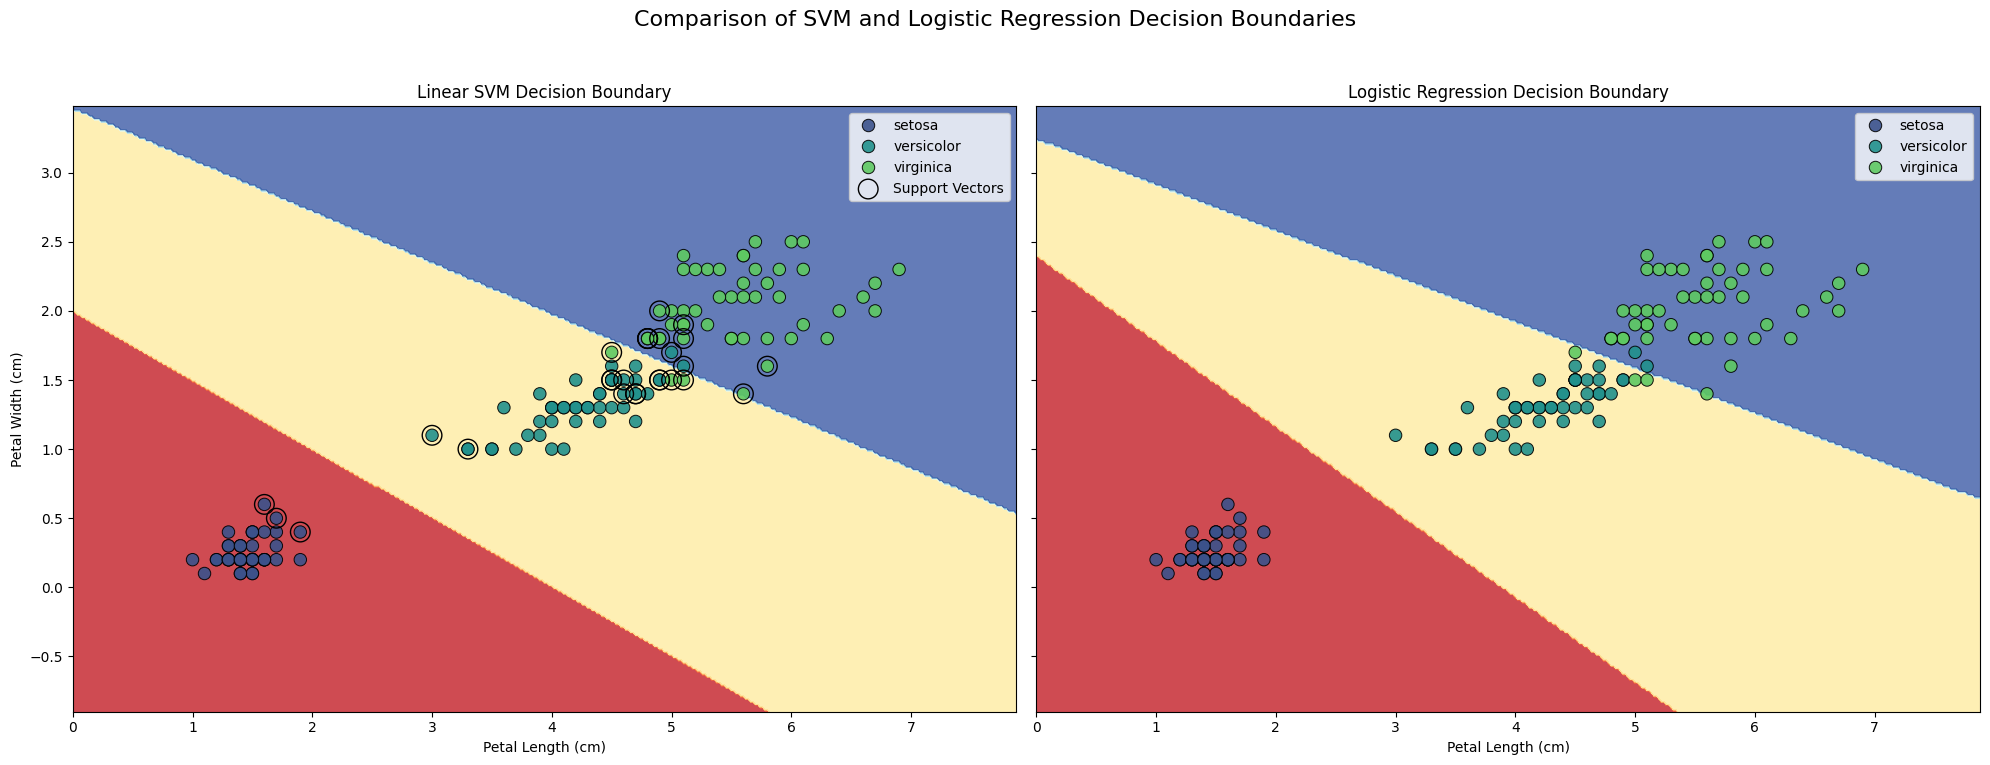

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

# --- Plot for Linear SVM Decision Boundary ---
# Plot the decision boundary for SVM
axes[0].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the actual data points for SVM
sns.scatterplot(
    x=df.iloc[:, 2], y=df.iloc[:, 3], hue=df['species'],
    palette='viridis', s=80, alpha=0.9, edgecolor='k', ax=axes[0]
)

# Plot support vectors
axes[0].scatter(support_vectors_original_2d[:, 0], support_vectors_original_2d[:, 1],
            s=200, facecolors='none', edgecolors='k', marker='o', label='Support Vectors')

axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Linear SVM Decision Boundary')
axes[0].legend()

# --- Plot for Logistic Regression Decision Boundary ---
# Plot the decision boundary for Logistic Regression
axes[1].contourf(xx, yy, Z_log_reg, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the actual data points for Logistic Regression
sns.scatterplot(
    x=df.iloc[:, 2], y=df.iloc[:, 3], hue=df['species'],
    palette='viridis', s=80, alpha=0.9, edgecolor='k', ax=axes[1]
)

axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Logistic Regression Decision Boundary')
axes[1].legend()

plt.suptitle('Comparison of SVM and Logistic Regression Decision Boundaries', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

### Evaluate Logistic Regression

In [29]:
# Make predictions on the scaled 2D test data using Logistic Regression
y_pred_log_reg = log_reg.predict(X_test_scaled_2d)

# Calculate accuracy for Logistic Regression
accuracy_log_reg = accuracy_score(y_test_2d, y_pred_log_reg)
print(f"Accuracy of Logistic Regression: {accuracy_log_reg:.4f}")

Accuracy of Logistic Regression: 1.0000


In [30]:
# Generate Confusion Matrix for Logistic Regression
conf_matrix_log_reg = confusion_matrix(y_test_2d, y_pred_log_reg)
print("\nConfusion Matrix for Logistic Regression:")
display(pd.DataFrame(conf_matrix_log_reg, index=log_reg.classes_, columns=log_reg.classes_))


Confusion Matrix for Logistic Regression:


,setosa,versicolor,virginica
setosa,19,0,0
versicolor,0,13,0
virginica,0,0,13


In [31]:
# Generate Classification Report for Logistic Regression
class_report_log_reg = classification_report(y_test_2d, y_pred_log_reg)
print("\nClassification Report for Logistic Regression:")
print(class_report_log_reg)


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### Summary of Performance Comparison

Now, let's summarize the key performance metrics side-by-side to easily compare the Linear SVM and Logistic Regression models.

In [32]:
print("\n--- Performance Comparison ---")
print("\nLinear SVM:")
print(f"  Accuracy: {accuracy_linear_svm:.4f}")
print("  Confusion Matrix:\n")
display(pd.DataFrame(conf_matrix_linear_svm, index=svm_linear.classes_, columns=svm_linear.classes_))
print("  Classification Report:\n")
print(class_report_linear_svm)

print("\nLogistic Regression (2D Features):\n")
print(f"  Accuracy: {accuracy_log_reg:.4f}")
print("  Confusion Matrix:\n")
display(pd.DataFrame(conf_matrix_log_reg, index=log_reg.classes_, columns=log_reg.classes_))
print("  Classification Report:\n")
print(class_report_log_reg)


--- Performance Comparison ---

Linear SVM:
  Accuracy: 0.9778
  Confusion Matrix:



,setosa,versicolor,virginica
setosa,19,0,0
versicolor,0,12,1
virginica,0,0,13


  Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


Logistic Regression (2D Features):

  Accuracy: 1.0000
  Confusion Matrix:



,setosa,versicolor,virginica
setosa,19,0,0
versicolor,0,13,0
virginica,0,0,13


  Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.